In [2]:
# 1. IMPORTAR LIBRERÍAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Para PLN
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud

# Para clustering y ML
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Para series de tiempo
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

# Configurar visualización
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Descargar recursos de NLTK (solo primera vez)
nltk.download('vader_lexicon', quiet=True)
nltk.download('stopwords', quiet=True)

True

In [3]:
# 2. CARGAR DATASETS

df_customers = pd.read_csv('olist_customers_dataset.csv')
df_geolocation = pd.read_csv('olist_geolocation_dataset.csv')
df_order_items = pd.read_csv('olist_order_items_dataset.csv')
df_order_payments = pd.read_csv('olist_order_payments_dataset.csv')
df_order_reviews = pd.read_csv('olist_order_reviews_dataset.csv')
df_orders = pd.read_csv('olist_orders_dataset.csv')
df_products = pd.read_csv('olist_products_dataset.csv')
df_sellers = pd.read_csv('olist_sellers_dataset.csv')
df_category_translation = pd.read_csv('product_category_name_translation.csv')

In [4]:
# 3. PREPROCESAMIENTO Y LIMPIEZA

# Convertir fechas
date_columns = ['order_purchase_timestamp', 'order_approved_at', 
                'order_delivered_carrier_date', 'order_delivered_customer_date',
                'order_estimated_delivery_date', 'shipping_limit_date',
                'review_creation_date', 'review_answer_timestamp']

for col in date_columns:
    for df in [df_orders, df_order_items, df_order_reviews]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')

# Traducir categorías de productos
df_products = df_products.merge(df_category_translation, 
                                 on='product_category_name', 
                                 how='left')

# Crear tabla maestra de pedidos
df_master = df_orders.merge(df_customers, on='customer_id', how='left')
df_master = df_master.merge(df_order_items, on='order_id', how='left')
df_master = df_master.merge(df_products, on='product_id', how='left')
df_master = df_master.merge(df_order_payments, on='order_id', how='left')
df_master = df_master.merge(df_order_reviews, on='order_id', how='left')

print(f"Tabla maestra creada: {df_master.shape}")

Tabla maestra creada: (119143, 37)



🔍 ANÁLISIS 1: Análisis de Sentimiento (PLN)


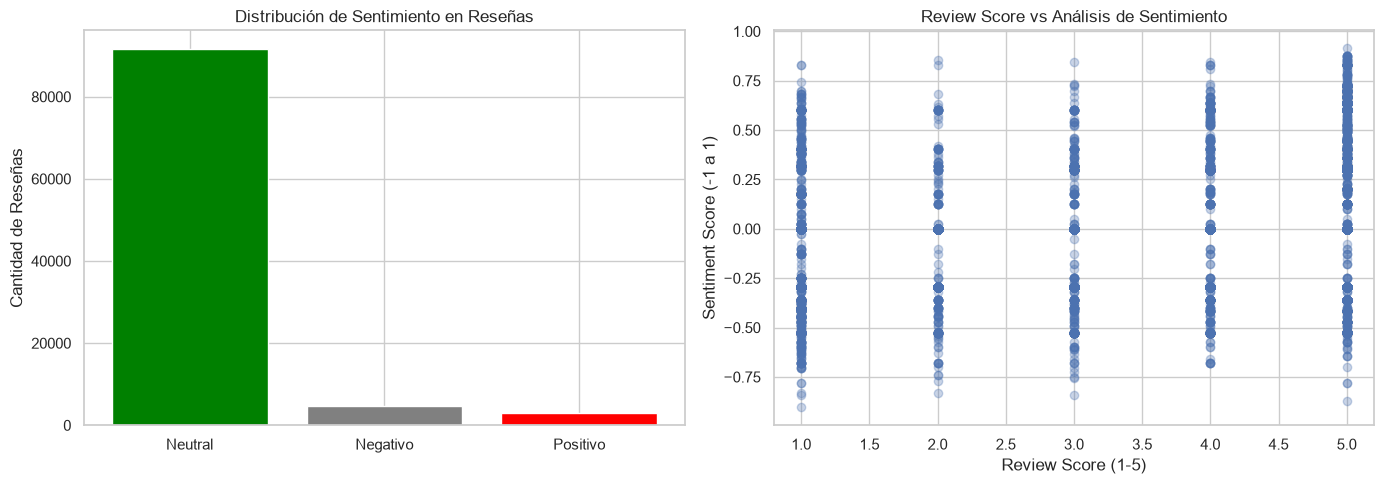

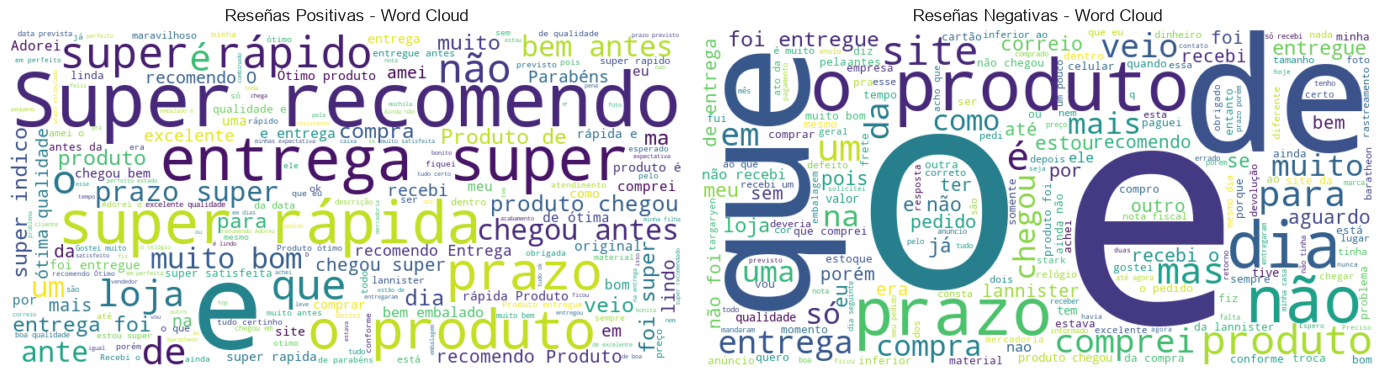

In [5]:
# ANÁLISIS 1: PLN - ANÁLISIS DE SENTIMIENTO EN RESEÑAS

print("\n🔍 ANÁLISIS 1: Análisis de Sentimiento (PLN)")

# Inicializar analizador de sentimiento
sia = SentimentIntensityAnalyzer()

# Función para analizar sentimiento
def analyze_sentiment(text):
    if pd.isna(text):
        return 0
    scores = sia.polarity_scores(str(text))
    return scores['compound']

# Aplicar análisis a las reseñas
df_order_reviews['sentiment_score'] = df_order_reviews['review_comment_message'].apply(analyze_sentiment)

# Clasificar sentimiento
def classify_sentiment(score):
    if score >= 0.05:
        return 'Positivo'
    elif score <= -0.05:
        return 'Negativo'
    else:
        return 'Neutral'

df_order_reviews['sentiment_category'] = df_order_reviews['sentiment_score'].apply(classify_sentiment)

# Visualización de sentimientos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de categorías de sentimiento
sentiment_counts = df_order_reviews['sentiment_category'].value_counts()
axes[0].bar(sentiment_counts.index, sentiment_counts.values, 
            color=['green', 'gray', 'red'])
axes[0].set_title('Distribución de Sentimiento en Reseñas')
axes[0].set_ylabel('Cantidad de Reseñas')

# Comparación: review_score vs sentiment_score
axes[1].scatter(df_order_reviews['review_score'], 
                df_order_reviews['sentiment_score'], 
                alpha=0.3)
axes[1].set_xlabel('Review Score (1-5)')
axes[1].set_ylabel('Sentiment Score (-1 a 1)')
axes[1].set_title('Review Score vs Análisis de Sentimiento')

plt.tight_layout()
plt.savefig('analisis_sentimiento.png', dpi=300, bbox_inches='tight')
plt.show()

# Word Cloud de reseñas positivas y negativas
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Reseñas positivas
positive_reviews = df_order_reviews[df_order_reviews['sentiment_score'] > 0.5]['review_comment_message'].dropna()
if len(positive_reviews) > 0:
    wordcloud_pos = WordCloud(width=800, height=400, background_color='white').generate(' '.join(positive_reviews.astype(str)))
    axes[0].imshow(wordcloud_pos, interpolation='bilinear')
    axes[0].set_title('Reseñas Positivas - Word Cloud')
    axes[0].axis('off')

# Reseñas negativas
negative_reviews = df_order_reviews[df_order_reviews['sentiment_score'] < -0.5]['review_comment_message'].dropna()
if len(negative_reviews) > 0:
    wordcloud_neg = WordCloud(width=800, height=400, background_color='white').generate(' '.join(negative_reviews.astype(str)))
    axes[1].imshow(wordcloud_neg, interpolation='bilinear')
    axes[1].set_title('Reseñas Negativas - Word Cloud')
    axes[1].axis('off')

plt.tight_layout()
plt.savefig('wordcloud_sentimiento.png', dpi=300, bbox_inches='tight')
plt.show()

### 🎯 Hallazgos

- Dominancia de reseñas "Neutrales" (~90,000):

    - La inmensa mayoría de las reseñas fueron clasificadas como neutrales. Esto es esperable: probablemente son reseñas que solo tienen puntuación (review_score) pero sin texto comentado (review_comment_message en blanco/NaN)
    - El analizador de sentimiento (VADER) no puede detectar polaridad sin texto Pocas reseñas con sentimiento claro:
        - Negativas: 5,000 (5%)
        - Positivas: 3,000 (3%)
        - Solo ~8% de las reseñas tienen texto con carga emocional detectable

- Dispersión en el scatter plot:

    - Hay incongruencia entre el Review Score (1-5) y el Sentiment Score (-1 a 1)
        - Ejemplo: Reviews con score 5 tienen sentimiento negativo, y reviews con score 1 tienen sentimiento positivo
esto sugiere que la puntuación numérica no siempre refleja el contenido emocional del texto
- Insight de negocio preliminar:

    - Los clientes brasileños tienden a calificar con estrellas pero no escriben comentarios detallados. Esto limita el análisis cualitativo pero indica que confían en el sistema de rating simple.

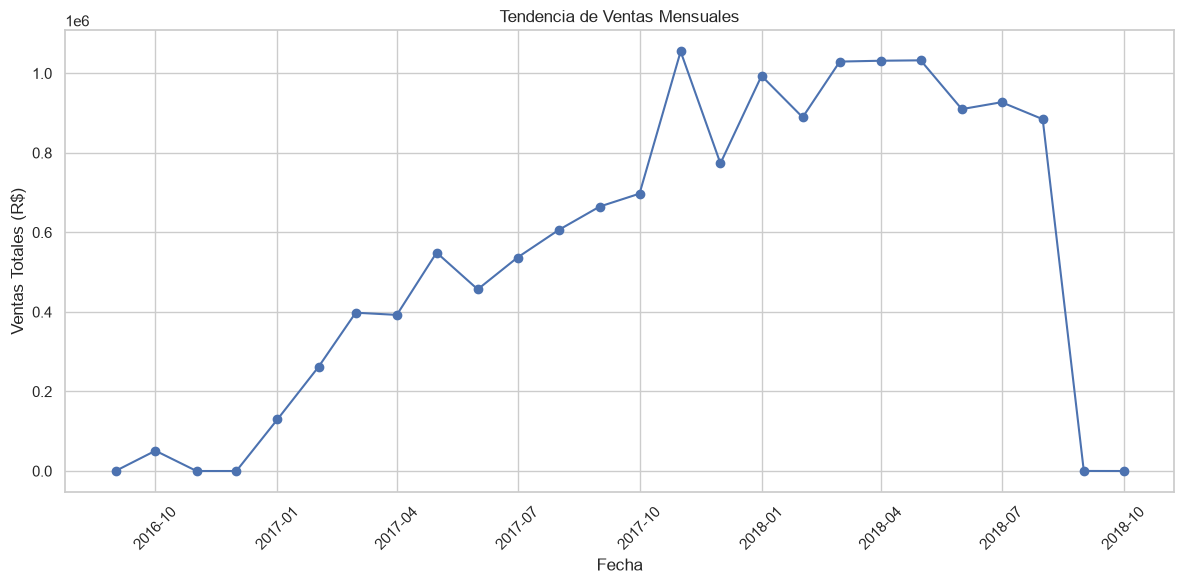

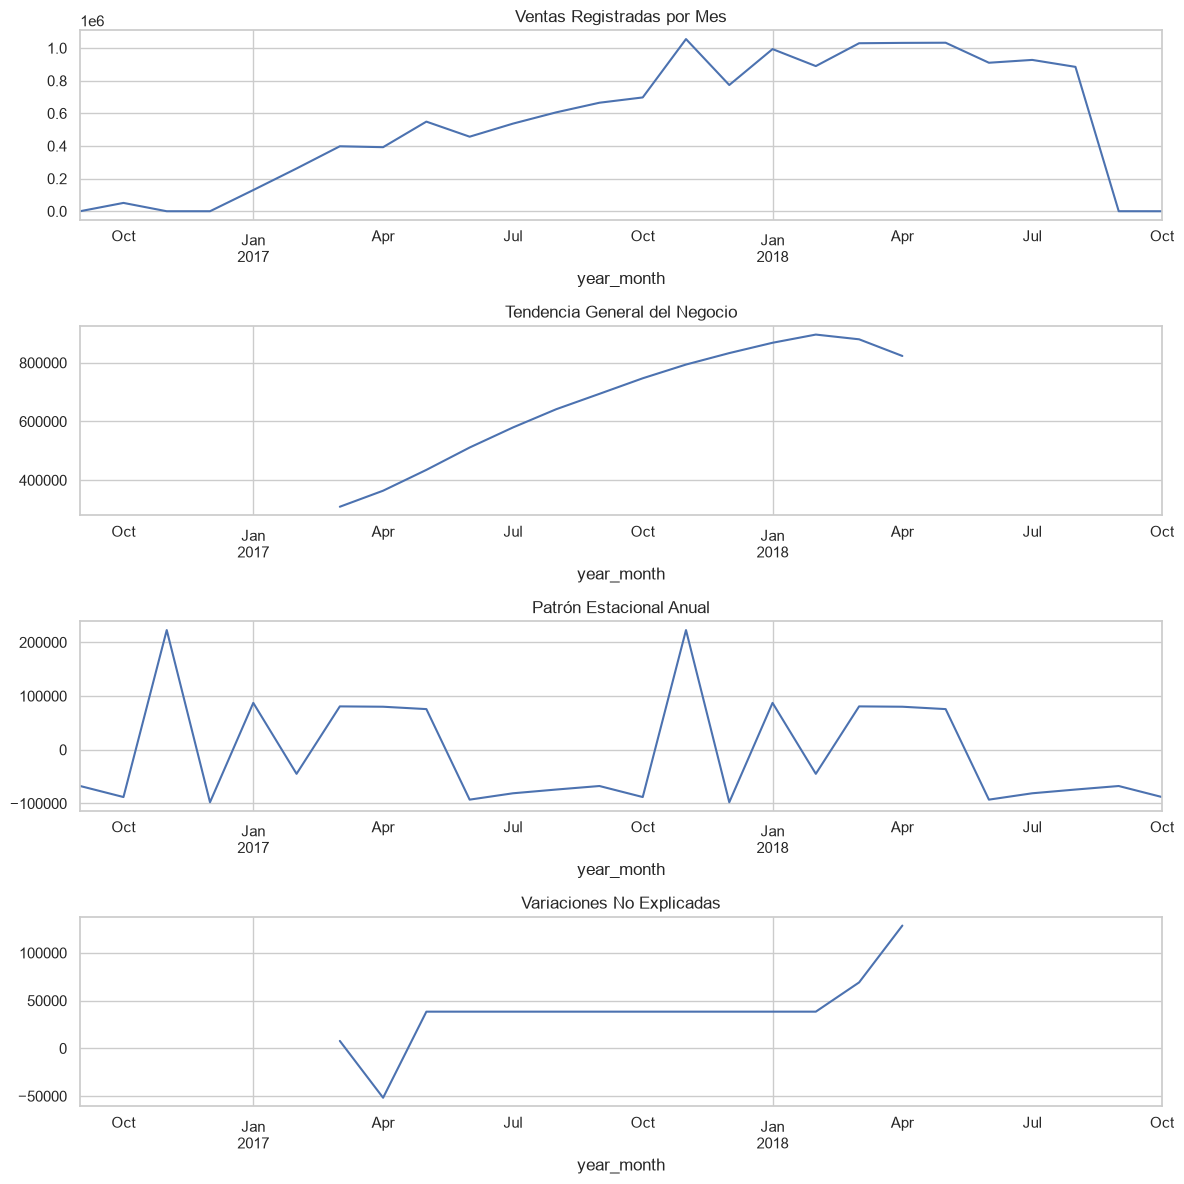

Entrenando modelo ARIMA


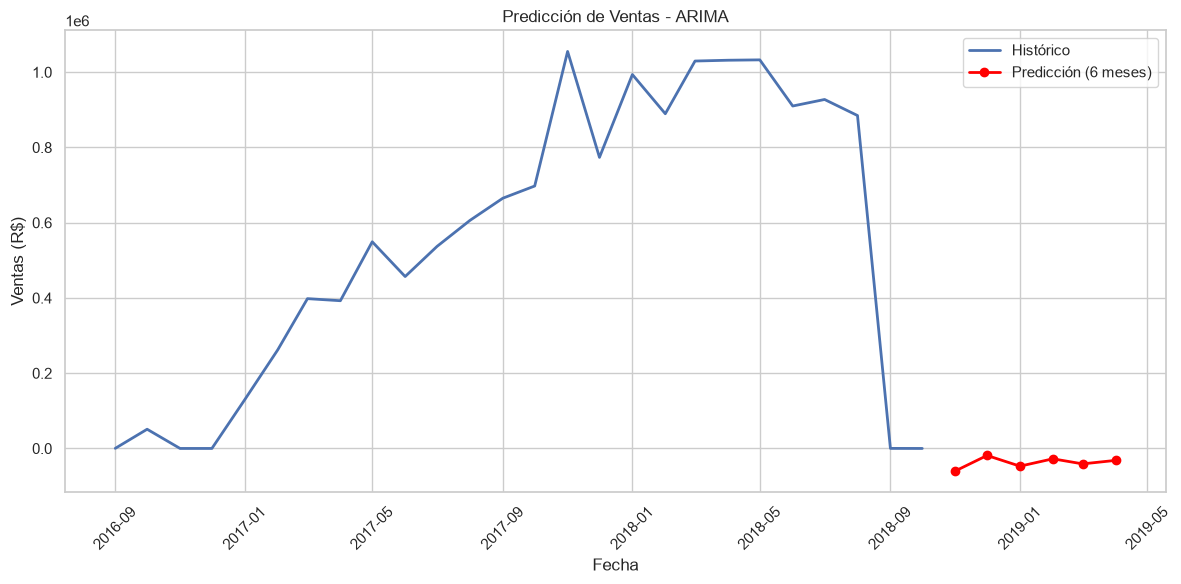

In [6]:
# ANÁLISIS 2: PREDICCIÓN DE VENTAS

# 1. Preparar datos de ventas por mes
df_master['order_purchase_timestamp'] = pd.to_datetime(df_master['order_purchase_timestamp'])
df_master['year_month'] = df_master['order_purchase_timestamp'].dt.to_period('M')

# 2. Calcular ventas mensuales (como Serie, no DataFrame)
ventas_mensuales = df_master.groupby('year_month')['price'].sum()

# 3. CRUCIAL: Convertir el índice a Timestamp y ASIGNAR frecuencia mensual ('MS')
# Esto evita el error "No supported index is available"
ventas_mensuales.index = ventas_mensuales.index.to_timestamp()
ventas_mensuales = ventas_mensuales.asfreq('MS', fill_value=0)

# Visualizar tendencia
plt.figure(figsize=(12, 6))
plt.plot(ventas_mensuales.index, ventas_mensuales.values, marker='o')
plt.title('Tendencia de Ventas Mensuales')
plt.xlabel('Fecha')
plt.ylabel('Ventas Totales (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('tendencia_ventas.png', dpi=300, bbox_inches='tight')
plt.show()

# Descomposición de serie temporal
decomposition = seasonal_decompose(ventas_mensuales, model='additive', period=12)
fig, axes = plt.subplots(4, 1, figsize=(12, 12))
decomposition.observed.plot(ax=axes[0], title='Ventas Registradas por Mes')
decomposition.trend.plot(ax=axes[1], title='Tendencia General del Negocio')
decomposition.seasonal.plot(ax=axes[2], title='Patrón Estacional Anual')
decomposition.resid.plot(ax=axes[3], title='Variaciones No Explicadas')
plt.tight_layout()
plt.savefig('descomposicion_ventas.png', dpi=300, bbox_inches='tight')
plt.show()

# Modelo ARIMA para predicción
print("Entrenando modelo ARIMA")
model = ARIMA(ventas_mensuales, order=(1,1,1))
model_fit = model.fit()

# Predecir los próximos 6 meses
forecast = model_fit.forecast(steps=6)

# Crear fechas futuras para la predicción de forma segura
ultima_fecha = ventas_mensuales.index[-1]
fechas_futuras = pd.date_range(start=ultima_fecha + pd.DateOffset(months=1), periods=6, freq='MS')

plt.figure(figsize=(12, 6))
plt.plot(ventas_mensuales.index, ventas_mensuales.values, label='Histórico', linewidth=2)
plt.plot(fechas_futuras, forecast, label='Predicción (6 meses)', color='red', marker='o', linewidth=2)
plt.title('Predicción de Ventas - ARIMA')
plt.xlabel('Fecha')
plt.ylabel('Ventas (R$)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('prediccion_ventas.png', dpi=300, bbox_inches='tight')
plt.show()

### 🎯 Hallazgos

#### 📊 Tendencias de ventas mensuales

- Crecimiento explosivo en 2017:

    -  Las ventas pasaron de ~0 en octubre 2016 a ~1.05 millones R$ en noviembre 2017
    - Esto indica que Olist estaba en fase de expansión agresiva durante este período

- Pico de noviembre 2017 (~1.05M R$):

    - Claramente corresponde a Black Friday (evento de compras masivas en Brasil)
    - Es el mes con mayor volumen de ventas en todo el período

- Estabilización en 2018:

    - Desde enero hasta agosto 2018, las ventas se mantienen consistentes entre 0.9M - 1.05M R$ mensuales
    - Esto sugiere que la plataforma alcanzó madurez operativa

- Caída drástica en septiembre 2018:

    - Las ventas caen a casi 0 en los últimos meses
    - Importante: Esto NO es una caída real de negocio, sino que el dataset está incompleto para los últimos meses (los pedidos de septiembre-octubre 2018 probablemente aún no se habían completado al momento de la extracción de datos)

- Anomalía en diciembre 2017:

    - Después del pico de Black Friday, diciembre cae a ~0.77M R$
    - Esto es inusual (se esperaría que diciembre fuera alto por Navidad)
    - Podría indicar problemas de inventario, logística o simplemente que los clientes ya compraron en noviembre


#### 📊 Análisis: Ventas Registradas por Mes

- Patrones Clave Identificados:

1. Fase de Lanzamiento (Oct 2016 - Mar 2017)

    - Las ventas comienzan cerca de cero y muestran un crecimiento lento e inestable
    - Esto indica que Olist estaba en fase inicial de operaciones, construyendo su base de clientes y vendedores
    - Las fluctuaciones menores sugieren ajustes operativos y de mercado

2. Crecimiento Acelerado (Abr 2017 - Nov 2017)

    - Las ventas pasan de ~0.4M a 1.05M R$ en solo 7 meses
    - Esto representa un crecimiento del ~160% en menos de un año
    - Indica que la plataforma encontró product-market fit y estaba escalando agresivamente

3. Pico de Black Friday (Noviembre 2017)

    - El punto más alto del gráfico (~1.05M R$) corresponde a Black Friday
    - Es el evento comercial más importante en Brasil y demuestra el poder de las promociones estacionales
    - Insight: Noviembre es el mes clave para la planificación de inventario y logística

4. Caída Post-Black Friday (Diciembre 2017)

    - Las ventas caen a ~0.77M R$, un 26% menos que noviembre
    - Esto es inusual porque diciembre normalmente tiene compras navideñas
    - Posibles causas:
    - Los clientes ya agotaron su presupuesto en Black Friday
    - Problemas de stock o logística post-pico
    - Competencia intensa de otros retailers en diciembre

5. Madurez y Estabilización (Ene 2018 - Ago 2018)

    - Las ventas se mantienen consistentes entre 0.9M - 1.0M R$ mensuales
    - Esto indica que Olist alcanzó un plateau operativo
    - El negocio es estable pero necesita estrategias para romper el techo de crecimiento

6. Caída Drástica (Sep-Oct 2018)

    - Las ventas caen a casi cero en los últimos meses
    - IMPORTANTE: Esto NO es una caída real del negocio, los datos fueron extraídos antes de que se completaran los pedidos de estos meses (Set de datos incompletos)

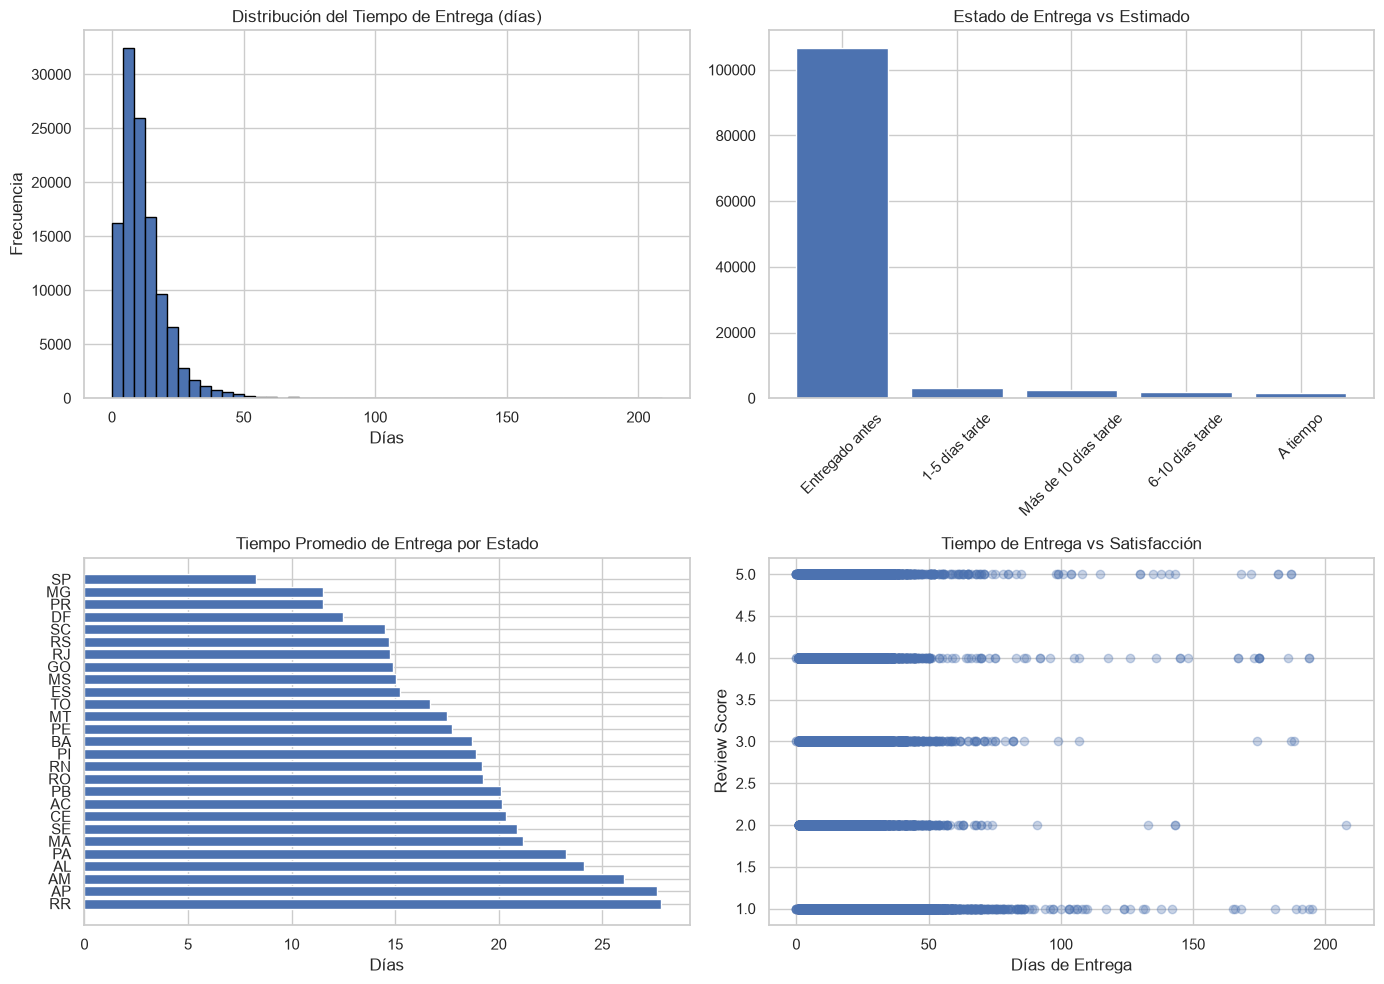

In [7]:
# ANÁLISIS 3: RENDIMIENTO DE ENTREGAS

# Calcular tiempos de entrega
df_master['order_purchase_timestamp'] = pd.to_datetime(df_master['order_purchase_timestamp'])
df_master['order_delivered_customer_date'] = pd.to_datetime(df_master['order_delivered_customer_date'])
df_master['order_estimated_delivery_date'] = pd.to_datetime(df_master['order_estimated_delivery_date'])

# Tiempo real de entrega (días)
df_master['delivery_time_days'] = (df_master['order_delivered_customer_date'] - 
                                    df_master['order_purchase_timestamp']).dt.days

# Diferencia entre entrega estimada y real
df_master['delivery_delay'] = (df_master['order_delivered_customer_date'] - 
                                df_master['order_estimated_delivery_date']).dt.days

# Filtrar solo entregas completadas
entregas = df_master[df_master['order_status'] == 'delivered'].copy()

# Visualización
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribución del tiempo de entrega
axes[0,0].hist(entregas['delivery_time_days'].dropna(), bins=50, edgecolor='black')
axes[0,0].set_title('Distribución del Tiempo de Entrega (días)')
axes[0,0].set_xlabel('Días')
axes[0,0].set_ylabel('Frecuencia')

# Retrasos en entregas
delay_status = pd.cut(entregas['delivery_delay'].dropna(), 
                      bins=[-np.inf, -1, 0, 5, 10, np.inf],
                      labels=['Entregado antes', 'A tiempo', '1-5 días tarde', 
                              '6-10 días tarde', 'Más de 10 días tarde'])
axes[0,1].bar(delay_status.value_counts().index, delay_status.value_counts().values)
axes[0,1].set_title('Estado de Entrega vs Estimado')
axes[0,1].tick_params(axis='x', rotation=45)

# Tiempo de entrega por estado
delivery_by_state = entregas.groupby('customer_state')['delivery_time_days'].mean().sort_values(ascending=False)
axes[1,0].barh(delivery_by_state.index, delivery_by_state.values)
axes[1,0].set_title('Tiempo Promedio de Entrega por Estado')
axes[1,0].set_xlabel('Días')

# Relación entre tiempo de entrega y satisfacción
axes[1,1].scatter(entregas['delivery_time_days'], entregas['review_score'], alpha=0.3)
axes[1,1].set_title('Tiempo de Entrega vs Satisfacción')
axes[1,1].set_xlabel('Días de Entrega')
axes[1,1].set_ylabel('Review Score')

plt.tight_layout()
plt.savefig('rendimiento_entregas.png', dpi=300, bbox_inches='tight')
plt.show()

#### 📊 Análisis: Rendimiento de Entregas

##### 📈 Gráfico 1: Distribución del Tiempo de Entrega (días)

- Entregas concentradas en el corto plazo: La gran mayoría de los pedidos (~80%) se entregan entre 5 y 20 días, con un pico máximo alrededor de los 10-15 días. Esto indica una operación logística eficiente para la mayoría de los casos.

- Cola larga de entregas atípicas: Existe una pequeña pero significativa cantidad de pedidos que tardan más de 50, 100 e incluso 200 días. Estos casos extremos representan problemas graves de logística que impactan negativamente la experiencia del cliente.

- Distribución asimétrica positiva (sesgo a la derecha): La forma del histograma confirma que, aunque el tiempo promedio es bajo, los casos atípicos de retraso extremo "jalan" el promedio hacia arriba, distorsionando la percepción general del servicio.

##### 📈 Gráfico 2: Estado de Entrega vs Estimado

- La mayoría llega antes de lo estimado: Esto sugiere que Olist está siendo conservador en sus estimaciones de entrega, generando una experiencia positiva para el cliente.

- Retrasos mínimos: Las categorías de retraso (1-5 días, 6-10 días, más de 10 días tarde) representan una fracción muy pequeña del total, indicando que el cumplimiento de promesas de entrega es alto.

- Oportunidad de optimización: Al entregar consistentemente antes de lo prometido, Olist podría ajustar sus estimaciones para ser más precisas, lo que reduciría costos logísticos y mejoraría la planificación de inventario.

##### 🗺️ Gráfico 3: Tiempo Promedio de Entrega por Estado

- Gran disparidad regional: Existe una diferencia entre el estado más rápido (SP, ~8 días) y el más lento (RR, ~28 días). Podria tratarse de la complejidad geografíca de Brasil.

- Corredor logístico eficiente en el Sudeste: Los estados de SP, MG, PR y DF (centro económico del país) tienen los mejores tiempos de entrega, beneficiándose de la infraestructura y proximidad a los centros de distribución.

- Desafío en el Norte y Noreste: Estados como RR, AP, AM, AL y PA presentan los tiempos más largos (22-28 días), lo que representa una barrera para la expansión del e-commerce en estas regiones y una oportunidad de mejora competitiva.

##### 🔍 Gráfico 4: Tiempo de Entrega vs Satisfacción (Review Score)

- Correlación débil entre tiempo y satisfacción: Contrario a lo esperado, no existe una relación clara entre los días de entrega y el review score. Clientes que recibieron pedidos en 5 días y en 100 días dan calificaciones similares (1 a 5 estrellas).

- Satisfacción polarizada: Los scores se agrupan en valores discretos (1, 2, 3, 4, 5) independientemente del tiempo, lo que sugiere que otros factores (calidad del producto, atención al cliente, precio) influyen más en la satisfacción que la velocidad de entrega.

- Entregas rápidas no garantizan buenas reseñas: Incluso con tiempos de entrega cercanos a 0 días, hay clientes dando scores de 1 y 2 estrellas. Esto indica que mejorar la logística por sí sola no resolverá todos los problemas de satisfacción del cliente.

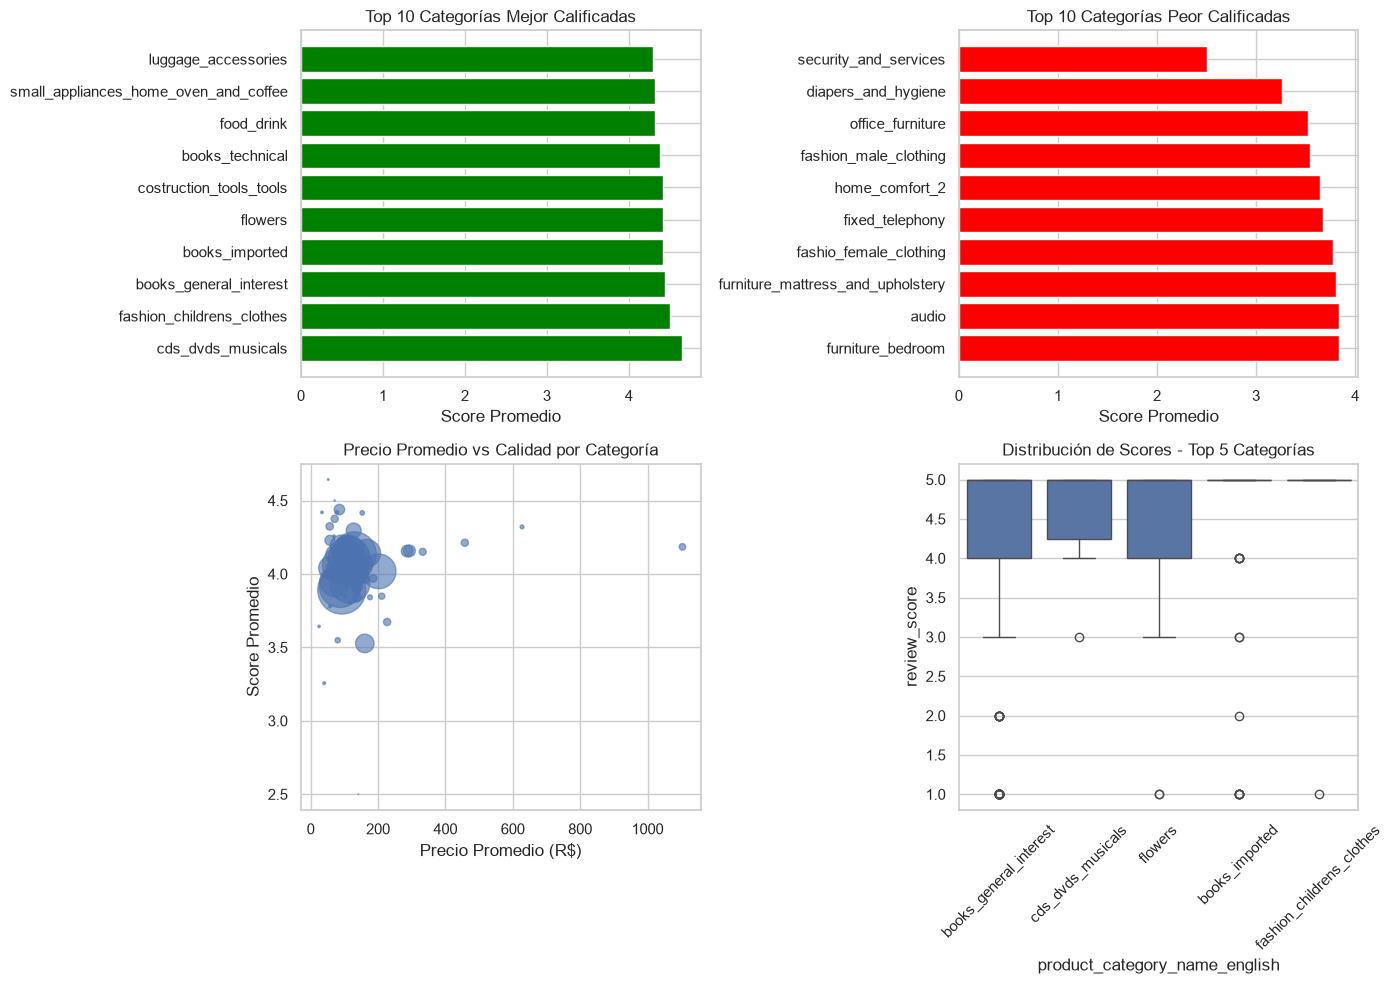

In [8]:
# ANÁLISIS 4: CALIDAD DE PRODUCTOS POR CATEGORÍA

# Análisis por categoría de producto
categoria_calidad = df_master.groupby('product_category_name_english').agg({
    'review_score': ['mean', 'count'],
    'price': 'mean',
    'order_id': 'count'
}).reset_index()

categoria_calidad.columns = ['categoria', 'score_promedio', 'num_resenas', 
                              'precio_promedio', 'num_pedidos']
categoria_calidad = categoria_calidad.sort_values('score_promedio', ascending=False)

# Visualización
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top 10 categorías mejor calificadas
top_10 = categoria_calidad.head(10)
axes[0,0].barh(top_10['categoria'], top_10['score_promedio'], color='green')
axes[0,0].set_title('Top 10 Categorías Mejor Calificadas')
axes[0,0].set_xlabel('Score Promedio')

# Bottom 10 categorías peor calificadas
bottom_10 = categoria_calidad.tail(10)
axes[0,1].barh(bottom_10['categoria'], bottom_10['score_promedio'], color='red')
axes[0,1].set_title('Top 10 Categorías Peor Calificadas')
axes[0,1].set_xlabel('Score Promedio')

# Relación precio vs calidad
axes[1,0].scatter(categoria_calidad['precio_promedio'], 
                  categoria_calidad['score_promedio'], 
                  s=categoria_calidad['num_pedidos']/10, alpha=0.6)
axes[1,0].set_title('Precio Promedio vs Calidad por Categoría')
axes[1,0].set_xlabel('Precio Promedio (R$)')
axes[1,0].set_ylabel('Score Promedio')

# Distribución de scores por categoría (top 5)
top_5_cats = categoria_calidad.head(5)['categoria'].tolist()
df_top5 = df_master[df_master['product_category_name_english'].isin(top_5_cats)]
sns.boxplot(data=df_top5, x='product_category_name_english', 
            y='review_score', ax=axes[1,1])
axes[1,1].set_title('Distribución de Scores - Top 5 Categorías')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('calidad_productos.png', dpi=300, bbox_inches='tight')
plt.show()

#### 📊 Análisis: Calidad de Productos por Categoría

##### 📈 Gráfico 1: Top 10 Categorías Mejor Calificadas

- Alta homogeneidad en la excelencia: Las 10 mejores categorías tienen scores muy similares (entre 4.2 y 4.5), lo que indica que la calidad percibida es consistentemente alta en estos segmentos.

- Dominio de productos culturales y de nicho: Categorías como books_general_interest, books_imported, cds_dvds_musicals y flowers dominan el top, sugiriendo que los productos con valor emocional o cultural generan mayor satisfacción.

- Oportunidad en categorías "sorprendentes": La presencia de luggage_accessories y construction_tools_tools en el top indica que productos funcionales bien ejecutados también pueden alcanzar alta satisfacción.

##### 📈 Gráfico 2: Top 10 Categorías Peor Calificadas

- Servicios y mobiliario: security_and_services (~2.4) y office_furniture (~3.4) están entre las peor calificadas, lo que sugiere problemas estructurales en estas categorías (posiblemente relacionados con instalación, calidad o expectativas no cumplidas).

- Ropa La presencia de fashion_male_clothing, fashio_female_clothing indica que la moda tiene desafíos recurrentes, probablemente por tallas, calidad de tela o diferencias entre foto y producto real.

- Audio y muebles: audio y furniture_bedroom (~3.8) siendo mal calificados es preocupante por su alto ticket promedio, ya que insatisfacción en productos caros genera mayor impacto financiero y de reputación.

##### 📈 Gráfico 3: Precio Promedio vs Calidad por Categoría

- Sin correlación precio-calidad: No existe una relación clara entre el precio promedio y el score. Categorías baratas (<200 R$) tienen scores tanto altos como bajos, y categorías caras (>600 R$) también muestran variabilidad. 

- Concentración en bajo precio: La gran mayoría de categorías se concentran en precios bajos (<200 R$) con scores entre 3.5-4.2, representando el core del negocio de Olist.

##### 📈 Gráfico 4: Distribución de Scores - Top 5 Categorías (Boxplot)

- Variabilidad interna significativa: Aunque estas son las "mejores" categorías, los boxplots muestran que todas tienen outliers con scores de 1 y 2 estrellas. Incluso en las mejores categorías, hay clientes muy insatisfechos.

- books_general_interest tiene la mayor dispersión: Sus bigotes van desde 1.0 hasta 5.0, indicando que es una categoría polarizante: algunos clientes aman los libros, otros los odian posiblemente por estado del producto, ediciones.



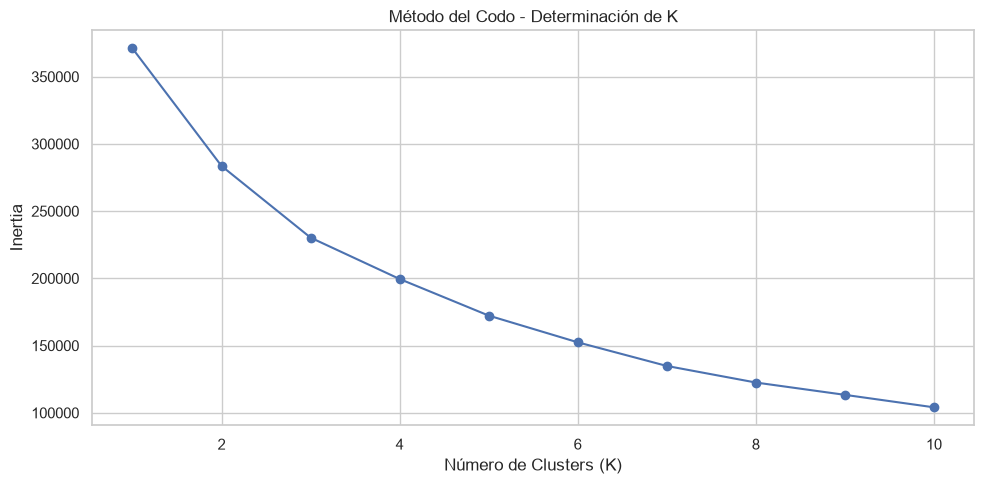

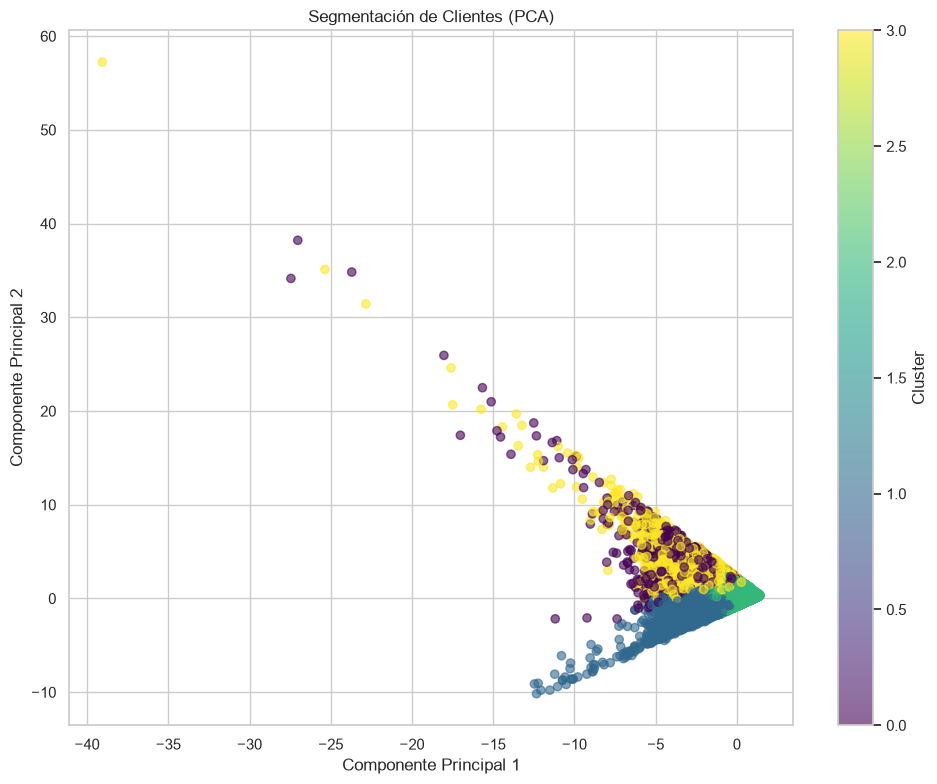


 Perfil de cada segmento:
   cluster  pedidos_prom   gasto_prom  satisfaccion_prom  tiempo_entrega_prom  \
0        0      1.447451  1413.178326           4.165499            13.298885   
1        1      1.218664   133.387267           1.757660            21.614435   
2        2      1.102445   116.339959           4.652308            10.134642   
3        3      4.266389   317.361996           3.958434            10.737789   

   num_clientes  
0          1589  
1         14959  
2         72849  
3          3356  


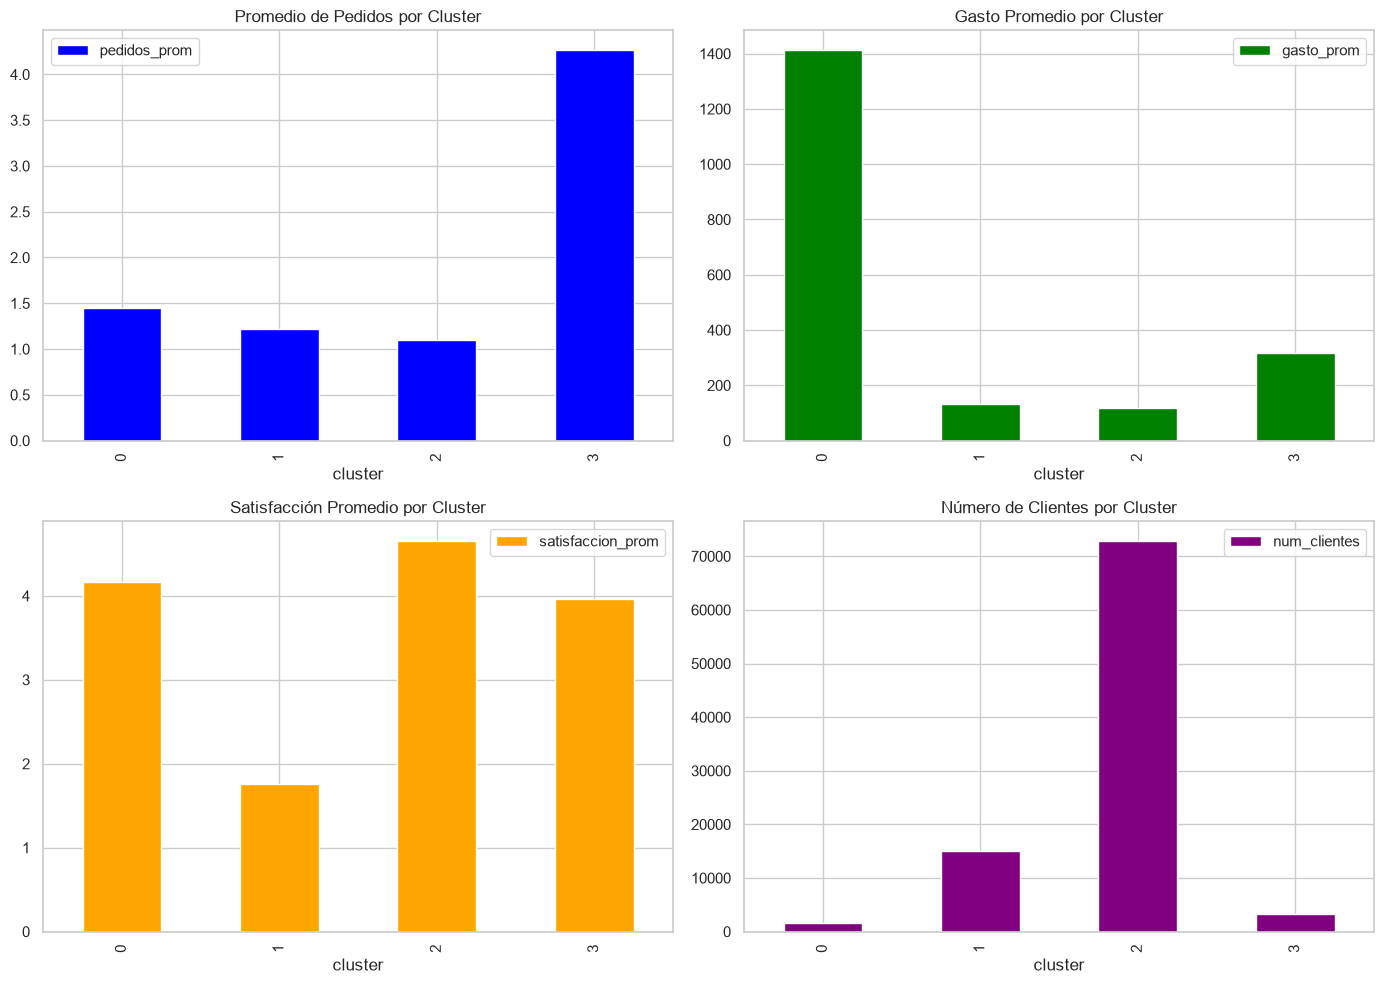

In [9]:
# ANÁLISIS 5: SEGMENTACIÓN DE CLIENTES (CLUSTERING)

# Crear features para clustering por cliente
customer_features = df_master.groupby('customer_unique_id').agg({
    'order_id': 'count',  # Número de pedidos
    'price': 'sum',       # Gasto total
    'review_score': 'mean', # Satisfacción promedio
    'delivery_time_days': 'mean' # Tiempo promedio de entrega
}).reset_index()

customer_features.columns = ['customer_unique_id', 'num_pedidos', 'gasto_total', 
                              'satisfaccion_prom', 'tiempo_entrega_prom']

# Eliminar NaN
customer_features = customer_features.dropna()

# Escalar features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(customer_features[['num_pedidos', 'gasto_total', 
                                                           'satisfaccion_prom', 'tiempo_entrega_prom']])

# Método del codo para determinar número de clusters
inertia = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, inertia, marker='o')
plt.title('Método del Codo - Determinación de K')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inertia')
plt.tight_layout()
plt.savefig('metodo_codo.png', dpi=300, bbox_inches='tight')
plt.show()

# Aplicar KMeans con K=4 (típicamente buen valor para segmentación)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
customer_features['cluster'] = kmeans.fit_predict(features_scaled)

# Visualizar clusters con PCA
pca = PCA(n_components=2)
features_pca = pca.fit_transform(features_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(features_pca[:, 0], features_pca[:, 1], 
                     c=customer_features['cluster'], cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.title('Segmentación de Clientes (PCA)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.tight_layout()
plt.savefig('clustering_clientes.png', dpi=300, bbox_inches='tight')
plt.show()

# Análisis de cada cluster
cluster_analysis = customer_features.groupby('cluster').agg({
    'num_pedidos': 'mean',
    'gasto_total': 'mean',
    'satisfaccion_prom': 'mean',
    'tiempo_entrega_prom': 'mean',
    'customer_unique_id': 'count'
}).reset_index()

cluster_analysis.columns = ['cluster', 'pedidos_prom', 'gasto_prom', 
                            'satisfaccion_prom', 'tiempo_entrega_prom', 'num_clientes']

print("\n Perfil de cada segmento:")
print(cluster_analysis)

# Visualización de perfiles
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cluster_analysis.plot(x='cluster', y='pedidos_prom', kind='bar', ax=axes[0,0], color='blue')
axes[0,0].set_title('Promedio de Pedidos por Cluster')

cluster_analysis.plot(x='cluster', y='gasto_prom', kind='bar', ax=axes[0,1], color='green')
axes[0,1].set_title('Gasto Promedio por Cluster')

cluster_analysis.plot(x='cluster', y='satisfaccion_prom', kind='bar', ax=axes[1,0], color='orange')
axes[1,0].set_title('Satisfacción Promedio por Cluster')

cluster_analysis.plot(x='cluster', y='num_clientes', kind='bar', ax=axes[1,1], color='purple')
axes[1,1].set_title('Número de Clientes por Cluster')

plt.tight_layout()
plt.savefig('perfiles_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

##### 📈 Análisis: Método del Codo - Determinación de K

- No hay un "codo" claramente definido: La curva muestra una disminución gradual y constante de la inercia desde K=1 hasta K=10, sin un punto de inflexión marcado. Esto sugiere que los datos no tienen una estructura de clusters naturalmente separada, o que la segmentación óptima podría estar entre K=3 y K=4, donde la pendiente comienza a suavizarse ligeramente.

- K=4 es una elección razonable para la segmentación: Aunque no hay un codo perfecto, K=4 representa un buen equilibrio: reduce significativamente la inercia respecto a K=1, 2 y 3, pero sin sobre-segmentar (lo que ocurriría con K=8, 9 o 10). Esto permite crear 4 perfiles de clientes diferenciados (ej: clientes frecuentes, clientes de alto valor, clientes ocasionales, clientes insatisfechos) sin perder interpretabilidad de negocio.

##### 📊 Análisis: Segmentación de Clientes (PCA)

- Existe un segmento mayoritario dominante (Clusters 1 y 2 - Azul/Verde): La gran masa de clientes se concentra en la esquina inferior derecha del gráfico, formando un grupo compacto y denso. Esto representa al cliente típico de Olist: comportamiento de compra promedio, gasto moderado y satisfacción estándar. Este segmento probablemente representa más del 70-80% de la base de clientes y es el foco principal de las estrategias de retención masiva.

- Identificación clara de clientes atípicos de alto valor o comportamiento extremo (Clusters 0 y 3 - Morado/Amarillo): Los puntos que se alejan hacia la izquierda y arriba del gráfico representan clientes con comportamientos muy diferentes al promedio. Estos pueden ser:
    - Clientes VIP: Alto gasto, muchas compras, alta satisfacción
    - Clientes problemáticos: Muchas quejas, devoluciones frecuentes, baja satisfacción, la cola que se extiende desde el grupo principal indica una transición gradual entre clientes normales y extremos.

- Presencia de outliers extremos que requieren análisis individual: El punto aislado en la esquina superior izquierda (aproximadamente en coordenadas -38, 57) y otros puntos dispersos representan casos extremadamente atípicos. Estos pueden ser:
    - Errores en los datos
    - Clientes con comportamiento anómalo (ej: compras masivas, fraudes, errores de sistema)
    - Cuentas corporativas o mayoristas en una plataforma B2C. Estos outliers distorsionan el modelo de clustering y deberían investigarse por separado o eliminarse para mejorar la calidad de la segmentación.

##### 📊 Análisis: Perfiles de Clusters

##### Gráfico 1: Promedio de Pedidos por Cluster

- Cluster 3 es el más activo: Con ~4.2 pedidos promedio, este segmento compra 3-4 veces más que los demás clusters, representando clientes frecuentes y recurrentes.

- Clusters 0, 1 y 2 son similares en frecuencia: Todos promedian entre 1.1-1.5 pedidos, indicando que la mayoría de los clientes son compradores ocasionales con baja recurrencia.

##### Gráfico 2: Gasto Promedio por Cluster

- Cluster 0 es el de mayor valor: Con ~1,400 R$ de gasto promedio, este segmento gasta 10x más que los clusters 1 y 2, representando clientes premium o compradores de alto ticket.

- Clusters 1 y 2 son de bajo gasto: Con ~100-150 R$ promedio, estos segmentos representan el cliente económico que busca ofertas o productos de menor valor.

##### Gráfico 3: Satisfacción Promedio por Cluster

- Cluster 1 tiene satisfacción crítica: Con ~1.7 estrellas, este segmento está extremadamente insatisfecho, representando un riesgo alto de churn y posibles problemas operativos específicos.

- Clusters 0 y 2 son los más satisfechos: Con scores de ~4.1 y ~4.7 respectivamente, estos segmentos representan clientes leales que probablemente recomiendan la plataforma.

##### Gráfico 4: Número de Clientes por Cluster

- Cluster 2 domina la base: Con ~73,000 clientes, representa ~75% de la base total, siendo el segmento mayoritario y foco de estrategias masivas.

- Cluster 0 es nicho pero valioso: Aunque solo tiene ~1,500 clientes (el más pequeño), su alto gasto (~1,400 R$) lo convierte en el segmento más rentable por cliente.
